In [1]:
################################################################################
###                                                                          ###
### Created by Haotian XIAO, 2024-2027                                       ###
###                                                                          ###
### École Polytechnique, Palaiseau, France                                   ###
###                                                                          ###
###                                                                          ###
### And Martin Genet, 2018-2025                                              ###
###                                                                          ###
### École Polytechnique, Palaiseau, France                                   ###
###                                                                          ###
################################################################################

#################################################################### imports ###

import os
import sys
import math
import dolfin
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import pyvista as pv

import myPythonLibrary as mypy
import dolfin_mech as dmech

def run_figure4_mode(
    mode,
    r0_list=(0.2,),
    probe_list=("gx", "gy"),
    perform_tests=0,
    beta=1.3,
):
    mode_to_folder = {
        "stretch-x": "results_Figure4_stretch_x",
        "stretch-y": "results_Figure4_stretch_y",
        "shear": "results_Figure4_shear",
        "pure-shear": "results_Figure4_pure_shear",
    }

    if mode not in mode_to_folder:
        raise ValueError("mode must be 'stretch-x', 'stretch-y', 'shear', or 'pure-shear'")

    res_folder = mode_to_folder[mode]
    os.makedirs(res_folder, exist_ok=True)

    test = mypy.Test(
        res_folder=res_folder,
        perform_tests=perform_tests,
        stop_at_failure=1,
        clean_after_tests=0,
        tester_numpy_tolerance=1e-2,
    )

    mat_params = {
        "alpha": 0.16,
        "gamma": 0.5,
        "c1": 0.2,
        "c2": 0.4,
        "kappa": 1,
        "eta": 1e-5,
    }

    dim = 2
    bcs = "pbc"

    print("mode =", mode)
    print("res_folder =", res_folder)
    print("dim =", dim)
    print("bcs =", bcs)

    def run_one_probe(r0, probe):
        pf = 0.0

        if probe == "gx":
            gx_ini_lst = [0.0, 0.01]
            gx_fin_lst = [0.01, 0.01]
            gy_ini_lst = [0.0, 0.0]
            gy_fin_lst = [0.0, 0.0]
        elif probe == "gy":
            gx_ini_lst = [0.0, 0.0]
            gx_fin_lst = [0.0, 0.0]
            gy_ini_lst = [0.0, 0.01]
            gy_fin_lst = [0.01, 0.01]
        else:
            raise ValueError("probe must be 'gx' or 'gy'")

        res_basename = f"Fig4-{mode}-r0={r0}-pf={pf}-{probe}"

        load_params = {
            "solid": {},
            "liquid": {},
            "air": {},
        }

        for i in range(dim):
            for j in range(dim):
                load_params["solid"]["sigma_bar_" + str(i) + str(j)] = 0.0

        n_steps = 2

        load_params["liquid"]["pl_bar_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["pl_bar_fin_lst"] = [0.0] * n_steps

        load_params["liquid"]["grad_p_bar_x_ini_lst"] = gx_ini_lst
        load_params["liquid"]["grad_p_bar_x_fin_lst"] = gx_fin_lst

        load_params["liquid"]["grad_p_bar_y_ini_lst"] = gy_ini_lst
        load_params["liquid"]["grad_p_bar_y_fin_lst"] = gy_fin_lst

        load_params["liquid"]["Theta_in_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_in_fin_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_fin_lst"] = [0.0] * n_steps

        if mode == "stretch-x":
            load_params["solid"]["U_bar_00_lst"] = [0.0, 0.3]

        elif mode == "stretch-y":
            load_params["solid"]["U_bar_11_lst"] = [0.0, 0.3]

        elif mode == "shear":
            load_params["solid"]["U_bar_00_lst"] = [0.0, 0.0]
            load_params["solid"]["U_bar_11_lst"] = [0.0, 0.0]
            load_params["solid"]["U_bar_01_lst"] = [0.0, 0.3]
            load_params["solid"]["U_bar_10_lst"] = [0.0, 0.0]


        elif mode == "pure-shear":
            load_params["solid"]["U_bar_00_lst"] = [0.0, beta - 1.0]
            load_params["solid"]["U_bar_11_lst"] = [0.0, 1.0 / beta - 1.0]

        load_params["air"]["pf"] = 0.0

        dmech.run_HollowBox_MicroPoroflow(
            dim=dim,
            mesh_params={
                "dim": dim,
                "xmin": 0.0,
                "ymin": -math.sqrt(3) / 2,
                "xmax": 1.0,
                "ymax": math.sqrt(3) / 2,
                "r0": r0,
                "l": 0.03,
                "hole_shape": "hex",
                "add_center_hole": True,
                "mesh_filebasename": res_folder + f"/mesh-r0={r0}",
            },
            mat_params={
                "skel": {"parameters": mat_params, "scaling": "no"},
                "bulk": {"parameters": mat_params, "scaling": "no"},
                "pore": {"parameters": mat_params, "scaling": "no"},
            },
            flow_params={
                "k_l": dolfin.Constant(
                    (
                        (1e-6, 0.0),
                        (0.0, 1e-6),
                    )
                ),
                "use_kozeny_carman": False,
            },
            porosity_params={
                "type": "constant",
                "val": 0.3,
            },
            bcs=bcs,
            step_params={
                "n_steps": n_steps,
                "Deltat_lst": [1e-2, 1e-1],
                "dt_ini_lst": [1e-3, 1e-3],
                "dt_min_lst": [1e-4, 1e-4],
                "dt_max_lst": [5e-3, 5e-3],
            },
            load_params=load_params,
            res_basename=res_folder + "/" + res_basename,
            verbose=0,
        )

        test.test(res_basename)

    for r0 in r0_list:
        for probe in probe_list:
            print(f"Running mode={mode}, r0={r0}, probe={probe}")
            run_one_probe(r0=r0, probe=probe)

    return res_folder

2026-06-19 16:14:57.434 (   0.103s) [          50D77E]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x144953e20): Unsupported cell type: 51 Setting to vtkEmptyCell
2026-06-19 16:14:57.434 (   0.104s) [          50D77E]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x144953e20): Unsupported cell type: 52 Setting to vtkEmptyCell
2026-06-19 16:14:57.434 (   0.104s) [          50D77E]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x144953e20): Unsupported cell type: 53 Setting to vtkEmptyCell
2026-06-19 16:14:57.434 (   0.104s) [          50D77E]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x144953e20): Unsupported cell type: 54 Setting to vtkEmptyCell
2026-06-19 16:14:57.434 (   0.104s) [          50D77E]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x144953e20): Unsupported cell type: 55 Setting to vtkEmptyCell
2026-06-19 16:14:57.434 (   0.104s) [          50D77E]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x144953e20): Unsupported cell type: 56 Sett

In [2]:
r0_list = [0.072, 0.315, 0.41, 0.5]
for mode in ["stretch-x", "stretch-y","shear"]:
    run_figure4_mode(
        mode=mode,
        r0_list=r0_list,
        probe_list=("gx", "gy"),
    )

mode = stretch-x
res_folder = results_Figure4_stretch_x
dim = 2
bcs = pbc
Running mode=stretch-x, r0=0.072, probe=gx
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%]

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Running mode=stretch-x, r0=0.072, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy

In [1]:
from pathlib import Path
import sys
r0_list = [0.072, 0.315, 0.41, 0.5]
PROJECT_DIR = Path.cwd().parents[0]
SRC_DIR = PROJECT_DIR / "src"

sys.path.insert(0, str(SRC_DIR))
print("PROJECT_DIR =", PROJECT_DIR)
print("SRC_DIR =", SRC_DIR)

from Plot_Microporoflow import plot_principal_K_vs_U

def build_figure4to6(mode, phi, r0_list, K_components=None):
    mode_to_folder = {
        "stretch-x": "results_Figure4_stretch_x",
        "stretch-y": "results_Figure4_stretch_y",
        "shear": "results_Figure4_shear",
        "pure-shear": "results_Figure4_pure_shear",
    }

    mode_to_xcomponent = {
        "stretch-x": "xx",
        "stretch-y": "yy",
        "shear": "xy",
        "pure-shear": "xx",
    }

    mode_to_figure_name = {
        "stretch-x": "Figure4_stretch-x.png",
        "stretch-y": "Figure5_stretch-y.png",
        "shear": "Figure6_shear.png",
        "pure-shear": "Figure6_pure-shear.png",
    }

    if mode not in mode_to_folder:
        raise ValueError("mode must be 'stretch-x', 'stretch-y','pure-shear' or 'shear'")

    res_folder = PROJECT_DIR / "demos" / mode_to_folder[mode]
    x_component = mode_to_xcomponent[mode]
    res_basename_prefix = f"Fig4-{mode}"

    save_name = PROJECT_DIR / "results" / "figures" / mode_to_figure_name[mode]
    save_name.parent.mkdir(parents=True, exist_ok=True)

    plot_principal_K_vs_U(
        res_folder=str(res_folder),
        res_basename_prefix=res_basename_prefix,
        r0_list=r0_list,
        pf_list=(0.0,),
        x_component=x_component,
        stream_density=0.6,
        stream_grid_n=500,
        stream_scale=1.0,
        add_stream_colorbar=True,
        save_name=str(save_name),
        show_plot=True,
    )

PROJECT_DIR = /Users/xiao/PhD/Project_MicroPoroFlow
SRC_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/src


2026-06-22 22:12:12.500 (   0.059s) [          691B71]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x10e8ea5c0): Unsupported cell type: 51 Setting to vtkEmptyCell
2026-06-22 22:12:12.500 (   0.059s) [          691B71]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x10e8ea5c0): Unsupported cell type: 52 Setting to vtkEmptyCell
2026-06-22 22:12:12.500 (   0.059s) [          691B71]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x10e8ea5c0): Unsupported cell type: 53 Setting to vtkEmptyCell
2026-06-22 22:12:12.500 (   0.059s) [          691B71]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x10e8ea5c0): Unsupported cell type: 54 Setting to vtkEmptyCell
2026-06-22 22:12:12.500 (   0.059s) [          691B71]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x10e8ea5c0): Unsupported cell type: 55 Setting to vtkEmptyCell
2026-06-22 22:12:12.500 (   0.059s) [          691B71]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x10e8ea5c0): Unsupported cell type: 56 Sett

[WARNING] Uyy differs between gx and gy probes for r0=0.072, pf=0.0
r0 = 0.072, pf = 0.0
K1_0 = 9.734762442214276e-07
K2_0 = 9.654762412521026e-07
max asymmetry = 5.656741225422957e-10


/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:540: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surf0 = mesh0.extract_surface().triangulate()
/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:557: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surf = warped.extract_surface().triangulate()


[WARNING] Uyy differs between gx and gy probes for r0=0.315, pf=0.0
[WARNING] Uxy differs between gx and gy probes for r0=0.315, pf=0.0
[WARNING] Uyx differs between gx and gy probes for r0=0.315, pf=0.0
r0 = 0.315, pf = 0.0
K1_0 = 5.354305022012239e-07
K2_0 = 5.333771416911919e-07
max asymmetry = 1.7373563213499188e-08
[WARNING] Uyy differs between gx and gy probes for r0=0.41, pf=0.0
[WARNING] Uxy differs between gx and gy probes for r0=0.41, pf=0.0
[WARNING] Uyx differs between gx and gy probes for r0=0.41, pf=0.0
r0 = 0.41, pf = 0.0
K1_0 = 3.240750861201487e-07
K2_0 = 3.234028540336227e-07
max asymmetry = 5.1621579624274e-09
[WARNING] Uyy differs between gx and gy probes for r0=0.5, pf=0.0
[WARNING] Uxy differs between gx and gy probes for r0=0.5, pf=0.0
[WARNING] Uyx differs between gx and gy probes for r0=0.5, pf=0.0
r0 = 0.5, pf = 0.0
K1_0 = 1.413648453774125e-07
K2_0 = 1.4127279523913283e-07
max asymmetry = 3.2398685396183826e-08


/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:1244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


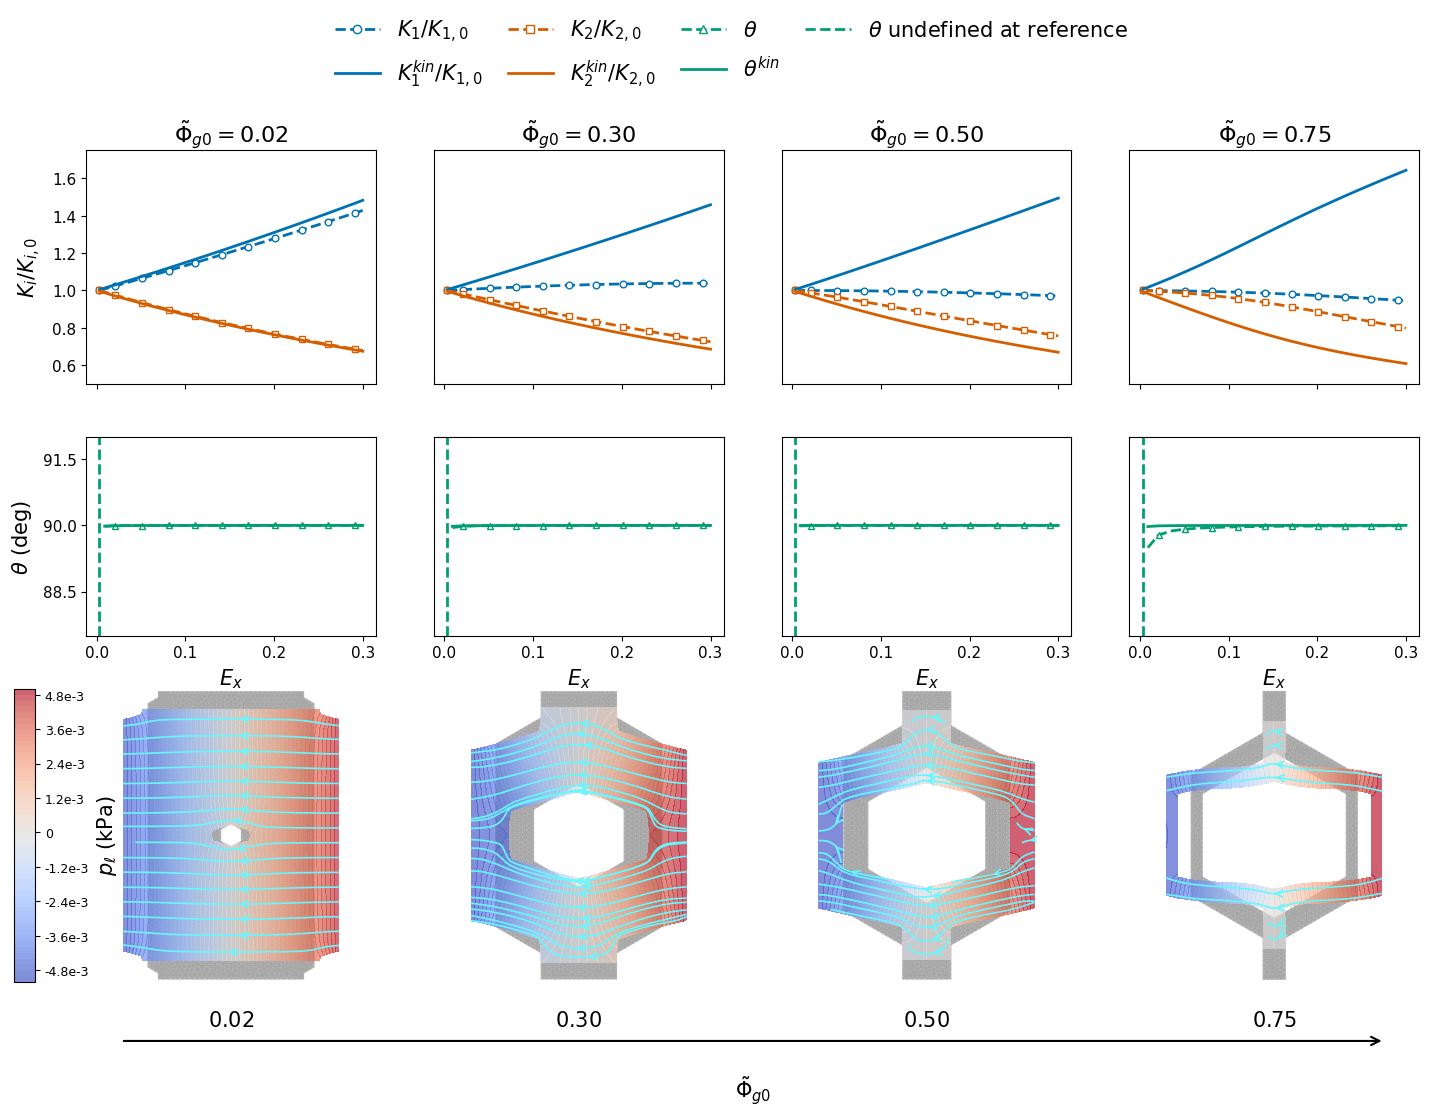

Saved: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure4_stretch-x.png


In [2]:
build_figure4to6("stretch-x", phi=0.3, r0_list=r0_list)

[WARNING] Uxx differs between gx and gy probes for r0=0.072, pf=0.0
r0 = 0.072, pf = 0.0
K1_0 = 9.734833058323566e-07
K2_0 = 9.654686466225244e-07
max asymmetry = 4.967479750525824e-10
[WARNING] Uxx differs between gx and gy probes for r0=0.315, pf=0.0
[WARNING] Uxy differs between gx and gy probes for r0=0.315, pf=0.0
[WARNING] Uyx differs between gx and gy probes for r0=0.315, pf=0.0
r0 = 0.315, pf = 0.0
K1_0 = 5.354547682109034e-07
K2_0 = 5.333532979957465e-07
max asymmetry = 1.9440776412126984e-08
[WARNING] Uxx differs between gx and gy probes for r0=0.41, pf=0.0
[WARNING] Uxy differs between gx and gy probes for r0=0.41, pf=0.0
[WARNING] Uyx differs between gx and gy probes for r0=0.41, pf=0.0
r0 = 0.41, pf = 0.0
K1_0 = 3.2407723612223157e-07
K2_0 = 3.2340273573202384e-07
max asymmetry = 1.1123719366928896e-08
[WARNING] Uxx differs between gx and gy probes for r0=0.5, pf=0.0
[WARNING] Uxy differs between gx and gy probes for r0=0.5, pf=0.0
[WARNING] Uyx differs between gx and gy p

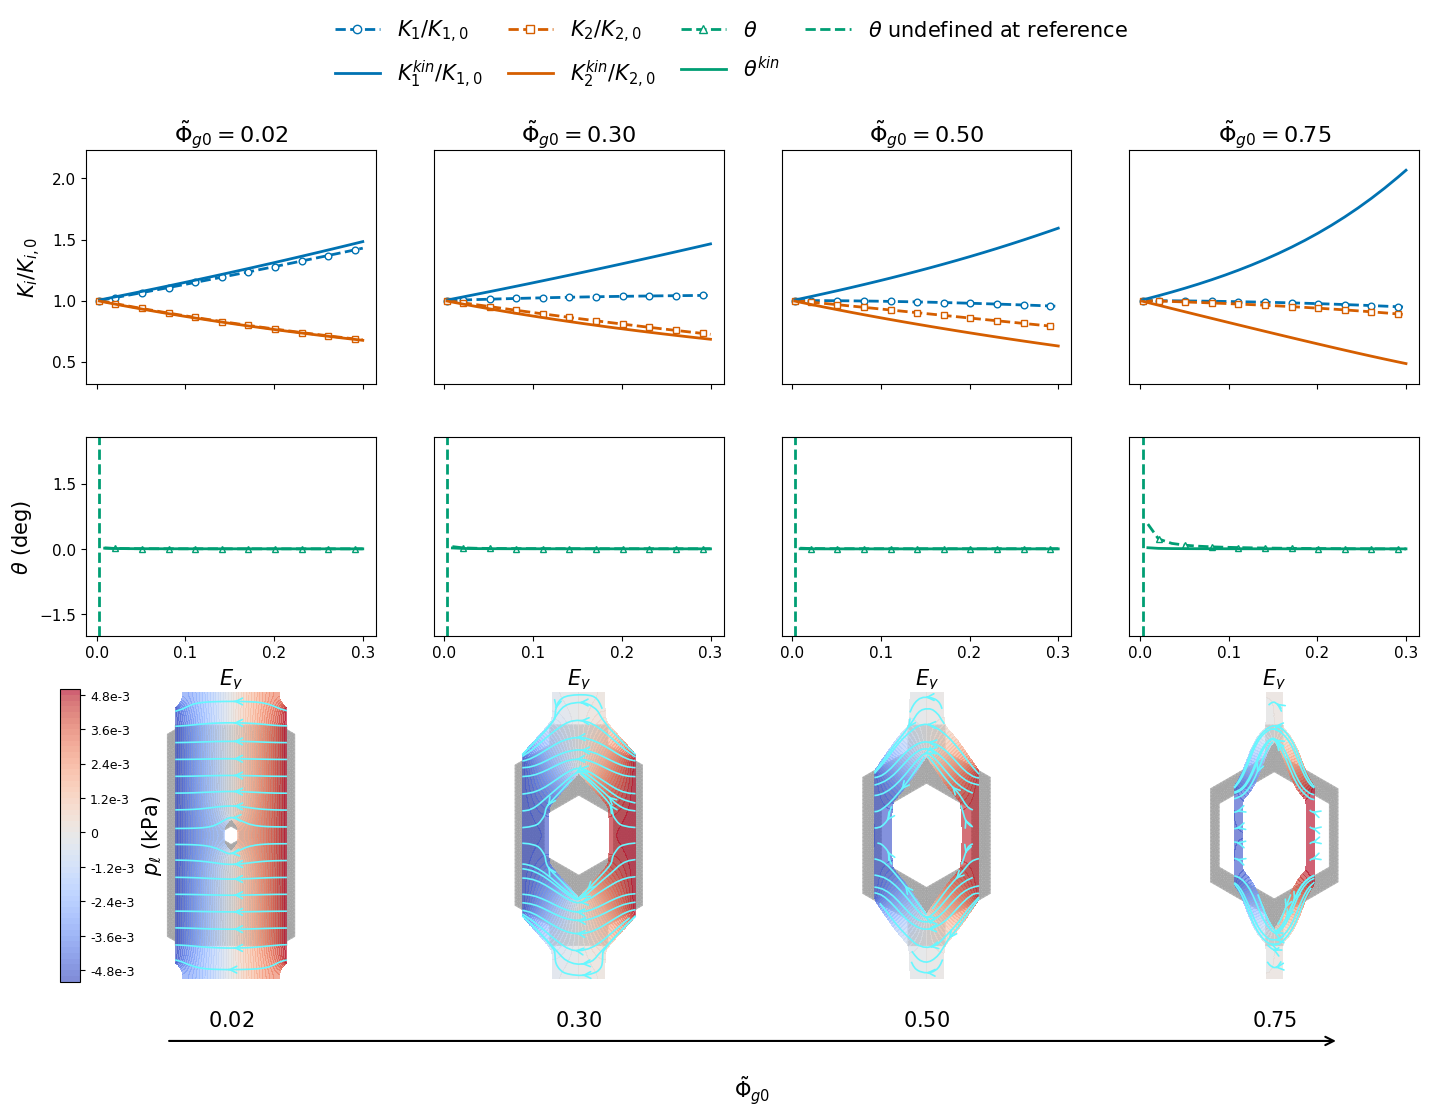

Saved: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure5_stretch-y.png


In [3]:
build_figure4to6("stretch-y", phi=0.3, r0_list=r0_list)

r0 = 0.072, pf = 0.0
K1_0 = 9.723712531831785e-07
K2_0 = 9.668201654154815e-07
max asymmetry = 2.3025936388291467e-08
r0 = 0.315, pf = 0.0
K1_0 = 5.357621241255822e-07
K2_0 = 5.342959455748092e-07
max asymmetry = 1.2453447779507e-07
r0 = 0.41, pf = 0.0
K1_0 = 3.24293859408892e-07
K2_0 = 3.2385401038364157e-07
max asymmetry = 1.3575826032723284e-07
r0 = 0.5, pf = 0.0
K1_0 = 1.4139324327070666e-07
K2_0 = 1.4135347620964808e-07
max asymmetry = 3.2667000253232534e-08


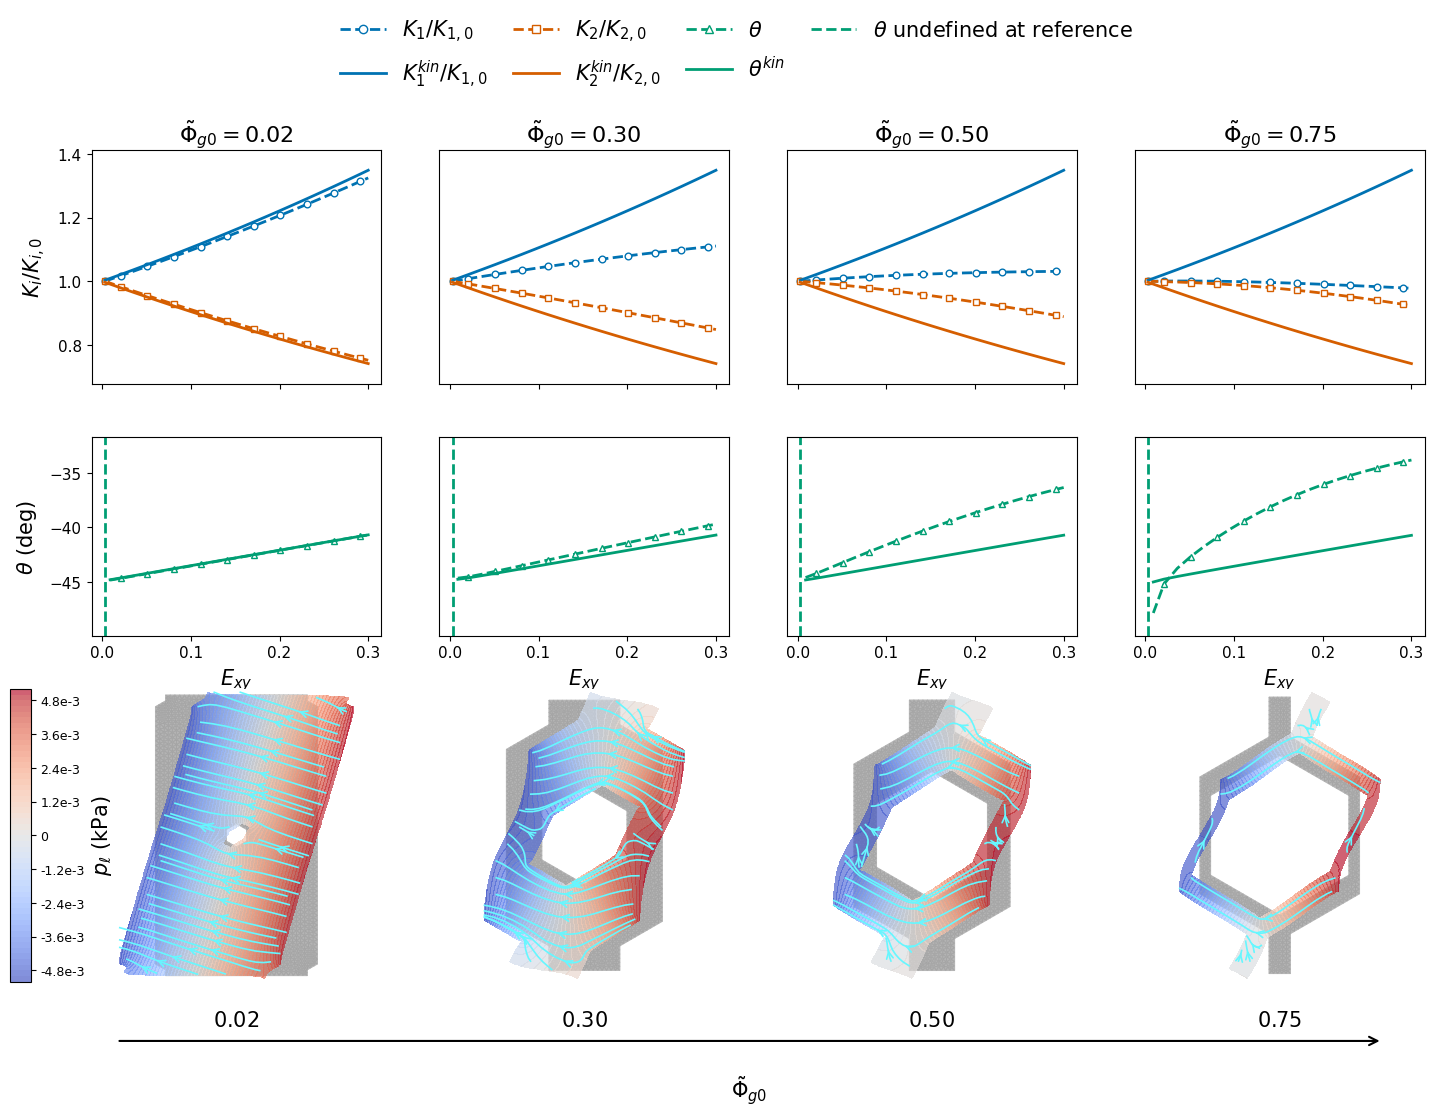

Saved: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure6_shear.png


In [4]:
build_figure4to6("shear", phi=0.3, r0_list=r0_list)